<a href="https://colab.research.google.com/github/aretiz/DAMSL-373/blob/main/tutorial_diffusionModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lets generate some numbers (again) 🔢

In [ ]:
from tqdm import tqdm
import os
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor, Normalize, Compose
from torch.utils.data import DataLoader
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import gc
from time import sleep

# UNet
Diffusion models often follow UNet-like architectures, which empirically provide the best results. UNet was originally proposed as a model for image segmentation, but it also has proven to be effective in diffusion models based on denoising, due to their ability to capture different levels of local and global features of an image.

UNet-like architectures are designed according to the following principles.



*   **Encoder-decoder structure**

The encoder captures the context and extracts high-level features from the input image, while the decoder reconstructs the segmented output by upsampling and combining the features from the encoder. This structure allows the network to learn both local and global information.

**IMPORTANT**: Do not get confused with variational autoencoders! In diffusion models, the encoder's output (a.k.a. latent variable) does not serve any specific purpose, except for one that will be discussed later. The encoder-decoder structure is mainly use to extract different types of features.


#Contracting path (Encoder)

In practice, starting from an image, the encoder gradually increases the number of channels and gradually decreases its dimensionality.

This is called a contracting path. For example, the tensor dimensionality may undergo the following transformations, going from the input to the latent space:

Input: 1x28x28 --> Intermediate 1: 64x14x14 --> Intermediate 2: 128x7x7 --> Intermediate 3: 256x3x3 --> Latent: 256x1x1



# Expanding path and skip connections (Decoder)
In denoising model, the decoder still has a "reverse" structure compared to the encoder. However, its purpose is to predict the next reconstruction step, rather than the entire image. Additionally, in the case of UNet, the encoder and the decoder are not separated, and we can take advantage of that.

In particular, we feed intermediate output of the encoder to the decoder layers. These are called "skip connections", since the intermediate outputs 'skip' part of the model.

![](https://theaisummer.com/static/2c373d3667071700748bf451c4e62b78/7f018/long-skip-connection.jpg)

In [ ]:
# This ConvBlock is the elementary block of UNet (for both encoder and decoder)
# ConvBlock preserves dimensionality
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.GroupNorm(8, out_channels),  # similar to BatchNormalization
            nn.ReLU(),
        )

    def forward(self, x):
        return self.block(x)


# Elementary encoder block
class UnetDown(nn.Module):
    def __init__(self, in_channels, out_channels, downscale=2):
        super(UnetDown, self).__init__()
        self.model = nn.Sequential(
            ConvBlock(in_channels, out_channels),
            nn.MaxPool2d(downscale)
        )

    def forward(self, x):

        return self.model(x)

# Encoder network
class Encoder(nn.Module):
    def __init__(self, n_features):
        super(Encoder, self).__init__()

        self.initial_features = nn.Sequential(
            nn.Conv2d(1, n_features, 3, 1, 1),
            nn.GroupNorm(8, n_features),
            nn.ReLU(),
        )
        self.down1 = UnetDown(n_features, n_features, downscale=2)
        self.down2 = UnetDown(n_features, 2*n_features, downscale=2)
        self.down3 = UnetDown(2*n_features, 2*n_features, downscale=2)
        self.down4 = nn.Sequential(
            nn.AvgPool2d(3),
            nn.ReLU())

    def forward(self, x):

        x_f = self.initial_features(x)
        d1 = self.down1(x_f)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        latent = self.down4(d3)
        return x_f, d1, d2, d3, latent

# UnetUp aims at reverting UnetDown, but also uses skip connections
# In some cases, output padding is needed (e.g., on the second layer,
# with upscale 2 we get Cx3x3--> C'x6x6, so we need extra_dim 1 to get C'x7x7)
class UnetUp(nn.Module):
    def __init__(self, in_channels, out_channels, upscale=2, extra_dim=0):
        super(UnetUp, self).__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, upscale, upscale, output_padding=extra_dim),
            ConvBlock(out_channels, out_channels),
            # ResBlock(out_channels),
        )

    def forward(self, x, skip):
        x = torch.cat((x, skip), 1)
        x = self.model(x)

        return x

# Decoder network
class Decoder(nn.Module):
    def __init__(self, n_features):
        super(Decoder, self).__init__()

        # first decoder layer does not have any skip connections
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(2*n_features, 2*n_features, 3, 3),
            nn.GroupNorm(8, 2*n_features),
            nn.ReLU(),

        )

        self.up2 = UnetUp(4*n_features, 2*n_features, upscale=2, extra_dim=1)
        self.up3 = UnetUp(4*n_features, n_features, upscale=2)
        self.up4 = UnetUp(2*n_features, n_features, upscale=2)
        self.out = nn.Conv2d(2*n_features, 1, 3, 1, 1)

    def forward(self, latent, d3, d2, d1, x_f):

        u1 = self.up1(latent)
        u2 = self.up2(u1, d3)
        u3 = self.up3(u2, d2)
        u4 = self.up4(u3, d1)
        eps_hat = self.out(torch.cat([u4, x_f], dim=1))
        return eps_hat

# Time embedding layer
class TimeEmbedding(nn.Module):
    def __init__(self, embedding_dim):
        super(TimeEmbedding, self).__init__()

        self.embedding_dim = embedding_dim
        self.lin1 = nn.Linear(1, embedding_dim, bias=False)
        self.lin2 = nn.Linear(embedding_dim, embedding_dim)

    def forward(self, ts):
        ts = ts.view(-1, 1)
        temb = torch.sin(self.lin1(ts))  # sine activation is common to encode time information
        temb = self.lin2(temb)
        temb = temb.view(-1, self.embedding_dim, 1, 1)  # add dummy channels to sum with latent
        return temb

# Overall Unet model
class Unet(nn.Module):

    def __init__(self, n_features=64):
        super(Unet, self).__init__()
        self.encoder = Encoder(n_features)
        self.decoder = Decoder(n_features)
        self.time_embedding_layer = TimeEmbedding(2*n_features)

    def forward(self, x, t):

        x_f, d1, d2, d3, latent = self.encoder(x)
        temb = self.time_embedding_layer(t)
        latent_temb = latent + temb
        eps_hat = self.decoder(latent_temb, d3, d2, d1, x_f)  # intermediate decoder steps are not needed

        return eps_hat

When training diffusion models, we gradually apply noise to our image, until the output is normally distributed with $\mathcal{N}(0, 1)$. The model is trained to invert this process and gradually reconstruct an image from noise.

![](https://raw.githubusercontent.com/thomasmarchioro3/hy673_tutorial11/1caec3fc7191c841287abafcddde227ffc8d74b8/figures/diff_intuition.png)

### Problem

Applying noise to get from $x_0$ to $x_t$ is normally an iterative procedure that requires sampling noise from a Gaussian distribution $t$ times, and averaging this noise with the image.
If we actually did this process in multiple iterations, training large diffusion models would be a very long procedure, sometimes infeasible.

Luckily, some smart mathematician came up with a method to pre-compute noise with one single step.

This method computes the noise parameters at step $t$ which are the $\bar{\alpha}_{t}$ coefficients in the algorithms below.

### Trick to apply multiple noise steps

During training (see loss function below), we need to go from $x_0$ to a specific $x_t$.

A single noise step gets applied according to $x_{t}\sim \mathcal{N}(\sqrt{1-\beta_t} x_{t-1}, \beta_t)$. $\beta_1$ and $\beta_T$ are hyperparameters, the other $\beta_t$ values are linearly spaced within the range $[\beta_1, \beta_T]$.

<b>Problem</b>: Producing $x_t$'s sequentially would be computationally expensive.

<b>Trick</b>: There is a formula to get $x_t$ directly from $x_0$
$$
x_t \sim \mathcal{N} (\sqrt{\bar{\alpha}_t} x_0, 1-\bar{\alpha}_t)
$$
with
$$
\alpha_t = 1 - \beta_t
$$
and
$$
\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s \ \ \text{(Cumulative product of $\alpha$'s)}
$$

In [ ]:
def get_schedules(beta_1, beta_T, n_T):
    """
    Linear scheduler.
    Useful to pre-compute all the parameters (even fractions, square roots, etc).
    """

    beta_t = (beta_T - beta_1) * torch.arange(0, n_T + 1, dtype=torch.float32) / n_T + beta_1
    sqrt_beta_t = torch.sqrt(beta_t)
    alpha_t = 1 - beta_t
    log_alpha_t = torch.log(alpha_t)
    alphabar_t = torch.cumsum(log_alpha_t, dim=0).exp()

    sqrt_abar = torch.sqrt(alphabar_t)
    one_over_sqrt_a = 1 / torch.sqrt(alpha_t)

    sqrt_inv_abar = torch.sqrt(1 - alphabar_t)
    inv_abar_over_sqrt_inv_abar = (1 - alpha_t) / sqrt_inv_abar

    return {
        "alpha": alpha_t,  # \alpha_t
        "one_over_sqrt_a": one_over_sqrt_a,  # 1/\sqrt{\alpha_t}
        "sqrt_beta": sqrt_beta_t,  # \sqrt{\beta_t}
        "alphabar": alphabar_t,  # \bar{\alpha_t}
        "sqrt_abar": sqrt_abar,  # \sqrt{\bar{\alpha_t}}
        "sqrt_inv_abar": sqrt_inv_abar,  # \sqrt{1-\bar{\alpha_t}}
        "inv_alpha_over_sqrt_inv_abar": inv_abar_over_sqrt_inv_abar,  # (1-\alpha_t)/\sqrt{1-\bar{\alpha_t}}
    }

In [ ]:
# Hyper parameters
epochs = 20  # If training takes too long you can reduce the number of epochs or increase the batch size
batch_size = 64
lr = 1e-5

n_T = 1000
betas = [1e-4, 0.02]

torch.manual_seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# Import dataset
transform = Compose([ToTensor(), Normalize((0.5,), (0.5,))])
dataset = MNIST("./data", train=True, download=True, transform=transform)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.39MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.32MB/s]


In [ ]:
# Initialize model, loss function, and optimizer
unet = Unet(n_features=128).to(device)
loss_fn = nn.MSELoss()
optim = Adam(unet.parameters(), lr=lr)

# pre-compute schedules
schedules = get_schedules(betas[0], betas[1], n_T)
schedules = {key: val.to(device) for key, val in schedules.items()}  # add all tensors on device

In [ ]:
# Create results directory if it does not exist
if not os.path.isdir('results'):
    os.makedirs('results')

if not os.path.isdir('saved_models'):
    os.makedirs('saved_models')

In [ ]:
# Sampling function (used to log the results)
def sample(model, n_T, n_samples, sample_shape, device, schedules):

    # Step 1
    x_T = torch.randn(n_samples, *sample_shape).to(device)
    ones = torch.ones(n_samples).to(device)

    # Step 2
    x_i = x_T
    for i in tqdm(range(n_T, 0, -1)):
        # Step 3
        z = torch.randn(n_samples, *sample_shape).to(device) if i > 1 else 0
        # Step 4
        t = (i / n_T)*ones
        eps = model(x_i, t)
        eps = eps.clone().detach()
        v = schedules["one_over_sqrt_a"][i] * (x_i - eps * schedules["inv_alpha_over_sqrt_inv_abar"][i])
        x_i = v + schedules["sqrt_beta"][i] * z


    # Step 6
    x = x_i
    return x

# Train the model

In [ ]:
# Training loop
losses = []
for epoch in range(epochs):
    print(f"Epoch {epoch+1} : ")

    # Set unet in training mode
    unet.train()

    pbar = tqdm(dataloader)
    for x, _ in pbar:
        x = x.to(device)
        x = x.view(-1, 1, 28, 28)

        # Step 3
        timesteps = torch.randint(1, n_T + 1, (x.shape[0],)).to(device)

        # Step 4
        eps = torch.randn_like(x)

        # Step 5
        optim.zero_grad()

        x_t = schedules["sqrt_abar"][timesteps, None, None, None] * x + schedules["sqrt_inv_abar"][timesteps, None, None, None] * eps
        t = timesteps/n_T
        eps_hat = unet(x_t, t)


        loss = loss_fn(eps_hat, eps)
        loss.backward()
        losses.append(loss.item())
        avg_loss = np.asarray(losses)[-10:].mean()
        pbar.set_description(f"Moving average loss: {avg_loss:.4f}")
        optim.step()

    # Set unet in eval mode
    unet.eval()
    with torch.no_grad():
        x_hat = sample(unet, n_T, 8, (1, 28, 28), device, schedules)
        grid = make_grid(x_hat, normalize=True, value_range=(-1, 1), nrow=4)

        # IMPORTANT: the grid contains
        save_image(grid, f"results/sample_mnist{epoch+1}.png")

        # save model
        torch.save(unet.state_dict(), f"saved_models/unet_mnist.pt")

Epoch 1 : 


100%|██████████| 1000/1000 [00:03<00:00, 298.78it/s]


Epoch 2 : 


100%|██████████| 1000/1000 [00:03<00:00, 294.99it/s]


Epoch 3 : 


...

100%|██████████| 1000/1000 [00:03<00:00, 290.13it/s]


Epoch 19 : 


100%|██████████| 1000/1000 [00:03<00:00, 296.67it/s]


Epoch 20 : 


100%|██████████| 1000/1000 [00:03<00:00, 304.35it/s]


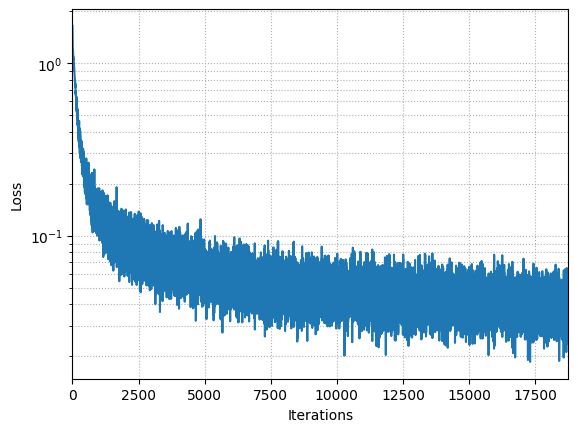

In [ ]:
plt.figure()
plt.semilogy(losses)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.xlim([0, len(losses)])
plt.grid(linestyle=':', which='both')
plt.draw()
plt.show()

#Generate new samples

In [ ]:
def sample(model, n_T, n_samples, sample_shape, device, schedules):

    # Step 1
    x_T = torch.randn(n_samples, *sample_shape).to(device)
    ones = torch.ones(n_samples).to(device)

    # Step 2
    x_i = x_T
    for i in tqdm(range(n_T, 0, -1)):
        # Step 3
        z = torch.randn(n_samples, *sample_shape).to(device) if i > 1 else 0
        # Step 4
        t = (i / n_T)*ones
        eps = model(x_i, t)

        # Very important: use eps.clone().detach() to avoid Out-of-memory errors
        # If eps stays connected to the computational graph, x_i will be connected to all
        # the tensors produced by the model
        eps = eps.clone().detach()
        v = schedules["one_over_sqrt_a"][i] * (x_i - eps * schedules["inv_alpha_over_sqrt_inv_abar"][i])
        x_i = v + schedules["sqrt_beta"][i] * z


    # Step 6
    x = x_i
    return x

In [ ]:
unet = Unet(n_features=128).to(device)

# pre-compute schedules
schedules = get_schedules(betas[0], betas[1], n_T)
schedules = {key: val.to(device) for key, val in schedules.items()}  # add all tensors on device

In [ ]:
loaded_state_dict = torch.load(f"saved_models/unet_mnist.pt", map_location=torch.device(device))
unet.load_state_dict(loaded_state_dict)
unet.eval()

Unet(
  (encoder): Encoder(
    (initial_features): Sequential(
      (0): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): GroupNorm(8, 128, eps=1e-05, affine=True)
      (2): ReLU()
    )
    (down1): UnetDown(
      (model): Sequential(
        (0): ConvBlock(
          (block): Sequential(
            (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): GroupNorm(8, 128, eps=1e-05, affine=True)
            (2): ReLU()
          )
        )
        (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (down2): UnetDown(
      (model): Sequential(
        (0): ConvBlock(
          (block): Sequential(
            (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): GroupNorm(8, 256, eps=1e-05, affine=True)
            (2): ReLU()
          )
        )
        (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  

100%|██████████| 1000/1000 [00:03<00:00, 274.54it/s]


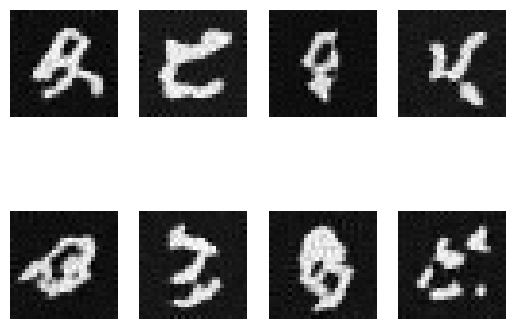

In [ ]:
n_samples = 8

x_hat = sample(unet, n_T, n_samples, (1, 28, 28), device, schedules)
x_hat = x_hat.detach().cpu().numpy().reshape(-1, 28, 28)

import matplotlib.pyplot as plt

for i, img in enumerate(x_hat):
    plt.subplot(2, 4, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.draw()